##### Imports

In [67]:
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler
from pathlib import Path

from gg570_d200.auxiliary_functions.overlap_funcs import propensity_scores, plot_propensity_scores, overlap_measures

In [68]:
root = Path.cwd().parent
data_path = root / "data"

In [69]:
root

PosixPath('/Users/gabrielgonzalezgalvan/Library/CloudStorage/OneDrive-UniversityofCambridge/Cambridge/Lent/ML Econ/Project/Repo')

---

##### Initial exploration and wrangling

In [70]:
df = pd.read_stata(data_path / "apsp_o24s25_eul_pwta22.dta", convert_categoricals=False)

In [71]:
df
# Training in past 3 months on current underemployment hours
# https://datacatalogue.ukdataservice.ac.uk/studies/study/9500#details
# https://doc.ukdataservice.ac.uk/doc/9500/mrdoc/pdf/9500_lfs_user_guide_vol3_variabledetails2022js.pdf
# https://doc.ukdataservice.ac.uk/doc/9500/mrdoc/pdf/9500_lfs_user_guide_vol6_aps_user_guide_2024.pdf
# https://doc.ukdataservice.ac.uk/doc/9500/mrdoc/pdf/9500_lfs_user_guide_vol2_questionnaire_2022jscombined.pdf
# https://doc.ukdataservice.ac.uk/doc/9500/mrdoc/pdf/9500_lfs_user_guide_vol6_aps_user_guide_2024.pdf

,AAGE,ACTHR,ACTHR2,ACTPOT,ACTUOT,ACTWKDY1,ACTWKDY2,ACTWKDY3,ACTWKDY4,ACTWKDY5,...,XDISDDA,Y2JOB,YLESS20,YMORE,YPAYL20,YPAYM,YPTJOB,YSTART,YTETJB,YVARY99
0,12,-9.0,-9.0,-9.0,-9.0,-9,-9,-9,-9,-9,...,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9
1,12,-9.0,-9.0,-9.0,-9.0,-9,-9,-9,-9,-9,...,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9
2,4,-9.0,-9.0,-9.0,-9.0,-9,-9,-9,-9,-9,...,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9
3,13,-9.0,-9.0,-9.0,-9.0,-9,-9,-9,-9,-9,...,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9
4,8,30.0,-9.0,0.0,0.0,2,3,5,-9,-9,...,-9,-9,13,-9,-9,-9,-9,-9,-9,-9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176025,9,-9.0,-9.0,-9.0,-9.0,1,2,3,4,5,...,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9
176026,2,-9.0,-9.0,-9.0,-9.0,-9,-9,-9,-9,-9,...,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9
176027,13,-9.0,-9.0,-9.0,-9.0,-9,-9,-9,-9,-9,...,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9
176028,13,-9.0,-9.0,-9.0,-9.0,-9,-9,-9,-9,-9,...,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9


In [72]:
df = df.drop(columns='idref')

In [73]:
df.rename(columns={'UNDHRS': 'Underemployment hours',
                   'ED13WK': 'Training (last 3 months)'}, inplace=True)

In [74]:
treatment_col = 'Training (last 3 months)'
outcome_col = 'Underemployment hours'

In [75]:
df[outcome_col].value_counts().sort_index()

Underemployment hours
-9.0     169490
 1.0         37
 1.5          3
 2.0        175
 2.5         33
          ...  
 56.0         1
 60.0         1
 72.0         1
 97.0         7
 99.0       274
Name: count, Length: 88, dtype: int64

In [76]:
df[treatment_col].value_counts().sort_index()

Training (last 3 months)
-9    99794
-8      194
 1    19670
 2    56372
Name: count, dtype: int64

In [77]:
df.dtypes.value_counts()

int8       493
int16       19
float64     16
str         11
int32        8
Name: count, dtype: int64

In [78]:
cols_to_adjust = list(df.select_dtypes(exclude=['number']).columns)

In [79]:
df.loc[:, cols_to_adjust].head()

,BANDG,BANDG2,BANDN,BANDN2,CTRY9D,FDSNGDEG,GOR9DCENSUS2021,PARK,REFDTE,SNGDEGN,SNGHD
0,-9,-9,-9,-9,E92000001,-9,E12000009,E65000001,06102024,-9,-9
1,-9,-9,-9,-9,E92000001,-9,E12000009,E65000001,06102024,-9,-9
2,-9,-9,-9,-9,E92000001,-9,E12000009,E65000001,06102024,-9,-9
3,-9,-9,-9,-9,E92000001,-9,E12000009,E65000001,06102024,-9,-9
4,-9,-9,-9,-9,E92000001,-9,E12000009,E65000001,06102024,-9,-9


In [80]:
cols_to_float = ['BANDG', 'BANDG2', 'BANDN', 'BANDN2']
df[cols_to_float] = df[cols_to_float].astype('float64')

In [81]:
cols_to_drop = [col for col in cols_to_adjust if col not in cols_to_float]
df = df.drop(columns=cols_to_drop, errors='ignore')
# Columns inspected using the dataset's documentation and deemed superfluous

In [82]:
df = df.drop(columns=df.columns[((df == -8) | (df == -9)).sum() / len(df) > 0.5].difference([treatment_col, outcome_col]), errors='ignore')
# Drop cols with more than 50% missing data

In [83]:
df = df[~((df == -8) | (df == -9)).any(axis=1)]
non_age_cols = df.columns.difference(['age', 'aage'])
df = df[~(df[non_age_cols] == 99).any(axis=1)]

In [84]:
set(df.nunique().sort_values(ascending=False))

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 31, 39, 48, 65, 830, 862, 1173}

In [85]:
constant_cols = [col for col in df.columns if df[col].nunique()==1]
df = df.drop(columns=constant_cols, errors='ignore')
# Drop cols with no variation

In [86]:
df.nunique()[df.nunique().between(31, 1173)].sort_values(ascending=False)

NPWT22                   1173
PWTA22                    862
PIWTA22                   830
Underemployment hours      65
AGE                        48
HIQUAL22                   39
HITQUA15                   31
REFWKD                     31
dtype: int64

In [87]:
df = df.drop(columns=['NPWT22', 'PWTA22', 'PIWTA22'])
# As before, columns inspected using the dataset's documentation and deemed irrelevant

In [88]:
df.nunique()[df.nunique().between(2, 15)].sort_values(ascending=False)

LKWFWM            15
CRYOX7_EUL_Sub    14
NSECM20           14
REFWKM            12
edageband         12
                  ..
QUAL21_11          2
QUAL21_13          2
QUAL21_14          2
QUAL21_15          2
WRKING             2
Length: 96, dtype: int64

In [89]:
cols_to_bin = list(df.columns[df.nunique().between(2, 15)].difference([treatment_col]))
for col in cols_to_bin:
    df = pd.concat([df, pd.get_dummies(pd.cut(df[col], bins=min(5, df[col].nunique())), prefix=f'{col}_bin', dtype=int)], axis=1)
    df = df.drop(columns=col)

In [90]:
df[treatment_col] = df[treatment_col].replace(2, 0)

In [91]:
covariate_cols = sorted([col for col in df.columns if col not in treatment_col and col not in outcome_col])

In [92]:
df = df[[outcome_col] + [treatment_col] + covariate_cols]

In [93]:
df.head()

,Underemployment hours,Training (last 3 months),"AAGE_bin_(1.99, 4.0]","AAGE_bin_(10.0, 12.0]","AAGE_bin_(4.0, 6.0]","AAGE_bin_(6.0, 8.0]","AAGE_bin_(8.0, 10.0]",AGE,"ANXIOUS_bin_(-0.01, 2.0]","ANXIOUS_bin_(2.0, 4.0]",...,"WORTH_bin_(4.0, 6.0]","WORTH_bin_(6.0, 8.0]","WORTH_bin_(8.0, 10.0]","WRKING_bin_(0.999, 1.5]","WRKING_bin_(1.5, 2.0]","edageband_bin_(10.916, 27.8]","edageband_bin_(27.8, 44.6]","edageband_bin_(44.6, 61.4]","edageband_bin_(61.4, 78.2]","edageband_bin_(78.2, 95.0]"
20,10.0,1,0,0,0,1,0,44,0,0,...,0,1,0,1,0,1,0,0,0,0
137,5.0,0,0,0,0,1,0,39,1,0,...,0,1,0,1,0,1,0,0,0,0
156,3.0,0,0,0,0,0,1,53,1,0,...,0,0,1,1,0,1,0,0,0,0
231,5.0,0,0,0,1,0,0,29,0,0,...,0,1,0,1,0,1,0,0,0,0
269,8.0,0,0,0,1,0,0,28,1,0,...,0,1,0,1,0,1,0,0,0,0


In [94]:
df.shape

(2020, 294)

In [95]:
df.to_csv(data_path / "df.csv", index=False)

---

##### Overlap

In [96]:
scaler = StandardScaler()

In [97]:
df_scaled = scaler.fit_transform(df[covariate_cols])
df_scaled = pd.DataFrame(df_scaled, columns=covariate_cols, index=df.index)

In [98]:
df_scaled[treatment_col] = df[treatment_col]
df_scaled[outcome_col] = df[outcome_col]
df_scaled['prop_scores'] = propensity_scores(df_scaled, covariate_cols, treatment_col)

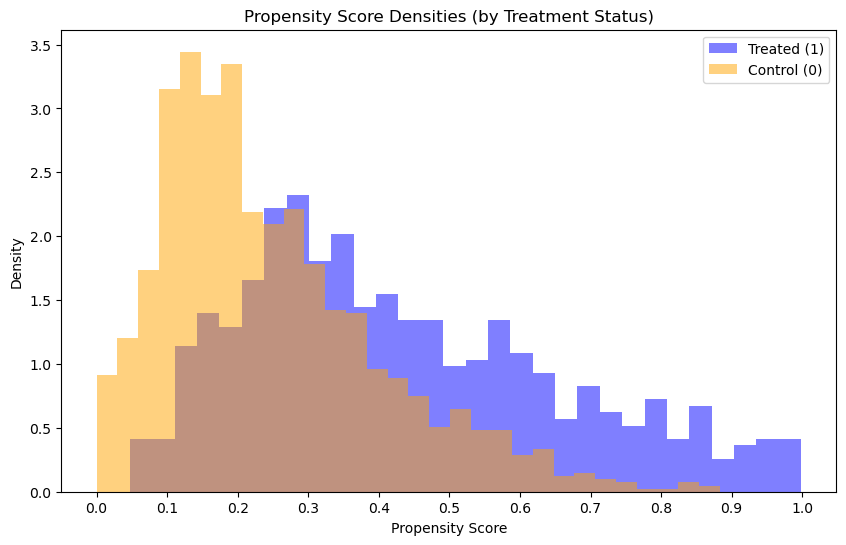

In [99]:
plot_propensity_scores(df_scaled, treatment_col, 'prop_scores')

In [100]:
true_extreme_scores_perc, true_ess_perc = overlap_measures(df_scaled, treatment_col, 'prop_scores')
true_extreme_scores_perc, true_ess_perc

(4.01, 58.13)

In [101]:
df_scaled.to_csv(data_path / "df_scaled.csv", index=False)

In [102]:
joblib.dump(
    {"scaler": scaler},
    data_path / "covariate_scaler.joblib"
)
print('Scaler saved')

Scaler saved
